# 02 - Clasificación contextual de transacciones

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Librerías
import platform
import sys
import unicodedata
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [3]:
#Configuración
SEMILLA = 20260724
UMBRAL_TRANSACCION = 0.50
UMBRAL_CONFIRMACION = 0.50
UMBRAL_REGULARIDAD = 0.60
VERSION_MODELO = 'fincoach_transacciones_mvp_v3'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'plataforma', 'version': platform.platform()},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
])

display(versiones)

,componente,version
0,python,3.14.3
1,plataforma,macOS-26.5.2-arm64-arm-64bit-Mach-O
2,pandas,3.0.3
3,numpy,2.5.1
4,scikit-learn,1.9.0


## 3. Carga del dataset

In [4]:
#Rutas
ruta_perfiles = Path('../Datasets/perfil_integral_usuario.csv')
ruta_transacciones = Path('../Datasets/transacciones_contextualizadas.csv')
ruta_modelo_usuario = Path('../Modelos/01_conocimiento_usuario.joblib')

assert ruta_perfiles.exists(), f'No existe {ruta_perfiles}'
assert ruta_transacciones.exists(), f'No existe {ruta_transacciones}'
assert ruta_modelo_usuario.exists(), 'Ejecuta primero el notebook 01 para generar su modelo'

print(f'Perfiles: {ruta_perfiles}')
print(f'Transacciones: {ruta_transacciones}')
print(f'Modelo de usuario: {ruta_modelo_usuario}')

Perfiles: ../Datasets/perfil_integral_usuario.csv
Transacciones: ../Datasets/transacciones_contextualizadas.csv
Modelo de usuario: ../Modelos/01_conocimiento_usuario.joblib


In [5]:
#Cargar datos
perfiles = pd.read_csv(ruta_perfiles, low_memory=False)
transacciones = pd.read_csv(ruta_transacciones, low_memory=False)
artefacto_usuario = joblib.load(ruta_modelo_usuario)

display(perfiles.head(5))
display(transacciones.head(5))

,perfil_id,version_perfil,vigencia_desde,pais,moneda,descripcion_visible,nivel_informacion_visible,estado_alcance_mvp,actividad_1_familia,actividad_1_codigo_cuoc,...,tiene_ingreso_adicional,ingreso_adicional,modalidad_ingreso_adicional,objetivo_proximo,hobbies,responsabilidad_financiera,tipos_deuda,nivel_endeudamiento_pct,estado_calculo_endeudamiento,habito_ahorro
0,PERF_0001,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Ingeniero de so...,parcial,dentro_del_mvp,ingenieria_y_desarrollo_de_software,25120,...,si,actividad independiente adicional,variable,crear fondo emergencia,pintura | turismo_y_viajes,gastos de un hijo,credito,4.93,calculado,media
1,PERF_0002,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Nutricionista d...,parcial,dentro_del_mvp,nutricion_y_dietetica,22650,...,no,NaN,NaN,ampliar actividad economica,cocina_y_reposteria | fotografia_y_video,aporte hogar compartido,credito,0.00,calculado,alta
2,PERF_0003,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Disc jockey. Es...,parcial,dentro_del_mvp,musica_y_entretenimiento_dj,26521,...,si,Editor de video / Editora de video,variable,no declarado,manualidades_y_artesanias | impresion_3d,no declarada,credito,3.16,calculado,baja
3,PERF_0004,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Ciclista. Estad...,parcial,dentro_del_mvp,deporte_competitivo_ciclismo,34210,...,no,NaN,NaN,no declarado,musica | fotografia_y_video,gastos de un hijo,credito,10.90,calculado,media
4,PERF_0005,perfil_estructurado_v2.0,2026-04-01,Colombia,COP,Actividad principal declarada: Repartidor de d...,parcial,dentro_del_mvp,domicilios_mensajeria_y_reparto,96211,...,no,NaN,NaN,no declarado,fotografia_y_video | ciclismo,apoyo parcial a dos familiares,credito,35.50,calculado,alta


,transaccion_id,perfil_id,version_perfil_aplicada,fecha,descripcion_original,descripcion_normalizada,valor,moneda,direccion,tipo_movimiento,...,fuente_etiqueta,ocurrencias_previas_90d,meses_previos_con_movimiento,dias_desde_movimiento_similar,variacion_valor_previa_pct,historial_regularidad_disponible,criterio_regularidad,fuente_regularidad,regularidad_confirmada_usuario,huella_registro
0,TX_0001_0001,PERF_0001,perfil_estructurado_v2.0,2026-04-02,PAGO ARRIENDO,pago arriendo,427000,COP,salida,gasto,...,historia_controlada_y_confirmacion_usuario,0,0,NaN,NaN,no,compromiso_periodico_predecible,regla_semantica_mvp_v3,no,df75d709f1fb24d34131658247a463a0064becede9d8df...
1,TX_0001_0002,PERF_0001,perfil_estructurado_v2.0,2026-04-02,ALMUERZO,almuerzo,54000,COP,salida,gasto,...,historia_controlada_y_confirmacion_usuario,0,0,NaN,NaN,no,recurrente_con_monto_o_decision_variable,regla_semantica_mvp_v3,no,c867f38949ce39522ff1b067e1c494168d1c20bcf872bc...
2,TX_0001_0003,PERF_0001,perfil_estructurado_v2.0,2026-04-03,REPUESTO TRANSPORTE,repuesto transporte,70000,COP,salida,gasto,...,historia_controlada_y_confirmacion_usuario,0,0,NaN,NaN,no,compra_o_consumo_no_periodico,regla_semantica_mvp_v3,no,a5e39c33c498c3ec2737aa6fab2fdc26c4445a64e29b88...
3,TX_0001_0004,PERF_0001,perfil_estructurado_v2.0,2026-04-03,HOTEL TURISMO,hotel turismo,90000,COP,salida,gasto,...,historia_controlada_y_confirmacion_usuario,0,0,NaN,NaN,no,recurrente_con_monto_o_decision_variable,regla_semantica_mvp_v3,no,0505855cc68b1d3c8e6238d0c7087d87b99dbc4d1d93b2...
4,TX_0001_0005,PERF_0001,perfil_estructurado_v2.0,2026-04-05,APP DOMICILIO COMIDA,app domicilio comida,53000,COP,salida,gasto,...,historia_controlada_y_confirmacion_usuario,0,0,NaN,NaN,no,compra_o_consumo_no_periodico,regla_semantica_mvp_v3,no,f5f9111421666b8f1d5dd5df444de11477bad274d24732...


## 4. Contrato y unión contextual

In [6]:
#Validar contrato
columnas_transacciones = [
    'transaccion_id',
    'perfil_id',
    'descripcion_original',
    'descripcion_normalizada',
    'valor',
    'direccion',
    'tipo_movimiento',
    'categoria_principal',
    'finalidad',
    'nota_usuario',
    'estado_clasificacion',
    'requiere_confirmacion',
    'regularidad_movimiento',
    'ocurrencias_previas_90d',
    'meses_previos_con_movimiento',
    'dias_desde_movimiento_similar',
    'variacion_valor_previa_pct',
    'historial_regularidad_disponible',
    'criterio_regularidad',
    'fuente_regularidad',
    'regularidad_confirmada_usuario',
    'particion',
]

columnas_perfiles = [
    'perfil_id',
    'actividad_principal_declarada',
    'actividad_1_familia',
    'estado_ingreso_actual',
    'ingreso_mensual_neto',
    'ingreso_adicional',
    'objetivo_proximo',
    'hobbies',
    'responsabilidad_financiera',
    'tipos_deuda',
    'nivel_endeudamiento_pct',
    'habito_ahorro',
]

faltantes_transacciones = [
    columna for columna in columnas_transacciones if columna not in transacciones.columns
]

faltantes_perfiles = [
    columna for columna in columnas_perfiles if columna not in perfiles.columns
]

assert not faltantes_transacciones, f'Faltan columnas en transacciones: {faltantes_transacciones}'
assert not faltantes_perfiles, f'Faltan columnas en perfiles: {faltantes_perfiles}'
assert transacciones['transaccion_id'].is_unique, 'transaccion_id contiene duplicados'
assert perfiles['perfil_id'].is_unique, 'perfil_id contiene duplicados'
assert set(transacciones['particion'].unique()) == {'train', 'validation', 'test'}, 'Particiones inválidas'

print('Contrato: OK')

Contrato: OK


In [7]:
#Contexto
datos = transacciones.merge(
    perfiles[columnas_perfiles],
    on='perfil_id',
    how='left',
    validate='many_to_one',
)

perfiles_sin_contexto = datos['actividad_principal_declarada'].isna().sum()
cruce_particiones = datos.groupby('perfil_id')['particion'].nunique()

assert perfiles_sin_contexto == 0, 'Existen transacciones sin perfil asociado'
assert cruce_particiones.eq(1).all(), 'Un perfil aparece en más de una partición'

display(pd.DataFrame([{
    'transacciones': len(datos),
    'perfiles': datos['perfil_id'].nunique(),
    'sin_contexto': int(perfiles_sin_contexto),
}]))

,transacciones,perfiles,sin_contexto
0,17284,200,0


## 5. Cobertura de etiquetas

In [8]:
#Mostrar cobertura
resumen_etiquetas = pd.DataFrame([
    {
        'objetivo': 'categoria_principal',
        'clases': datos['categoria_principal'].nunique(),
        'clase_menor': datos['categoria_principal'].value_counts().idxmin(),
        'filas_clase_menor': int(datos['categoria_principal'].value_counts().min()),
    },
    
    {
        'objetivo': 'finalidad',
        'clases': datos['finalidad'].nunique(),
        'clase_menor': datos['finalidad'].value_counts().idxmin(),
        'filas_clase_menor': int(datos['finalidad'].value_counts().min()),
    },
    
    {
        'objetivo': 'requiere_confirmacion',
        'clases': datos['requiere_confirmacion'].nunique(),
        'clase_menor': datos['requiere_confirmacion'].value_counts().idxmin(),
        'filas_clase_menor': int(datos['requiere_confirmacion'].value_counts().min()),
    },
    {
        'objetivo': 'regularidad_gastos',
        'clases': datos.loc[datos['direccion'].eq('salida'), 'regularidad_movimiento'].nunique(),
        'clase_menor': datos.loc[datos['direccion'].eq('salida'), 'regularidad_movimiento'].value_counts().idxmin(),
        'filas_clase_menor': int(datos.loc[datos['direccion'].eq('salida'), 'regularidad_movimiento'].value_counts().min()),
    },
    {
        'objetivo': 'regularidad_ingresos',
        'clases': datos.loc[datos['direccion'].eq('entrada'), 'regularidad_movimiento'].nunique(),
        'clase_menor': datos.loc[datos['direccion'].eq('entrada'), 'regularidad_movimiento'].value_counts().idxmin(),
        'filas_clase_menor': int(datos.loc[datos['direccion'].eq('entrada'), 'regularidad_movimiento'].value_counts().min()),
    },
])

display(resumen_etiquetas)
display(pd.crosstab(datos['categoria_principal'], datos['particion']))
display(pd.crosstab([datos['direccion'], datos['regularidad_movimiento']], datos['particion']))

,objetivo,clases,clase_menor,filas_clase_menor
0,categoria_principal,20,Rentas y rendimientos,13
1,finalidad,14,apoyo_externo,100
2,requiere_confirmacion,2,si,558
3,regularidad_gastos,2,fijo,5241
4,regularidad_ingresos,3,estacional,249


particion,test,train,validation
categoria_principal,,,
Alimentación,229,993,212
Apoyos recibidos,18,67,15
Deuda y financiación,88,441,124
Deuda y financiación recibida,21,98,23
Devoluciones y reembolsos,26,97,17
Educación,147,610,145
Ingresos laborales,53,275,58
Inversión productiva,261,1108,273
Ocio,363,1555,291


particion                         test  train  validation
direccion regularidad_movimiento                         
entrada   estacional                52    159          38
          fijo                     227   1462         208
          variable                  48    213          46
salida    fijo                     787   3640         814
          variable                1510   6657        1423

In [9]:
#Validar cobertura
cobertura_categoria = pd.crosstab(
    datos['categoria_principal'],
    datos['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

cobertura_finalidad = pd.crosstab(
    datos['finalidad'],
    datos['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

cobertura_regularidad_gastos = pd.crosstab(
    datos.loc[datos['direccion'].eq('salida'), 'regularidad_movimiento'],
    datos.loc[datos['direccion'].eq('salida'), 'particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

cobertura_regularidad_ingresos = pd.crosstab(
    datos.loc[datos['direccion'].eq('entrada'), 'regularidad_movimiento'],
    datos.loc[datos['direccion'].eq('entrada'), 'particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

assert cobertura_categoria.gt(0).all(axis=1).all(), 'Alguna categoría no aparece en las tres particiones'
assert cobertura_finalidad.gt(0).all(axis=1).all(), 'Alguna finalidad no aparece en las tres particiones'
assert cobertura_regularidad_gastos.gt(0).all(axis=1).all(), 'Alguna regularidad de gastos no aparece en las tres particiones'
assert cobertura_regularidad_ingresos.gt(0).all(axis=1).all(), 'Alguna regularidad de ingresos no aparece en las tres particiones'
print('Cobertura de etiquetas: OK')

Cobertura de etiquetas: OK


## 6. Ingeniería de atributos

In [10]:
#Preparar contexto
def valor_texto(valor, reemplazo='no_declarado'):
    if pd.isna(valor) or not str(valor).strip():
        return reemplazo
    return str(valor).strip()


datos['actividad_secundaria_modelo'] = datos['ingreso_adicional'].fillna('no_declarada')
datos['hobbies_modelo'] = datos['hobbies'].fillna('no_declarado')
datos['meta_modelo'] = datos['objetivo_proximo'].fillna('no_declarada')
datos['responsabilidad_modelo'] = datos['responsabilidad_financiera'].fillna('no_declarada')
datos['deuda_modelo'] = datos['tipos_deuda'].fillna('sin_deuda')
datos['endeudamiento_modelo'] = datos['nivel_endeudamiento_pct'].fillna('no_calculable')
datos['historial_disponible_modelo'] = datos['historial_regularidad_disponible'].eq('si').astype(int)

columnas_historial = [
    'ocurrencias_previas_90d',
    'meses_previos_con_movimiento',
    'dias_desde_movimiento_similar',
    'variacion_valor_previa_pct',
]

for columna in columnas_historial:
    datos[columna] = pd.to_numeric(datos[columna], errors='coerce')

columnas_historial_modelo = columnas_historial + ['historial_disponible_modelo']

In [11]:
#Construir atributos
def construir_texto_modelo(fila):
    partes = [
        'transaccion {}'.format(valor_texto(fila['descripcion_normalizada'])),
        'nota {}'.format(valor_texto(fila['nota_usuario'])),
        'direccion {}'.format(valor_texto(fila['direccion'])),
        'tipo {}'.format(valor_texto(fila['tipo_movimiento'])),
        'actividad {}'.format(valor_texto(fila['actividad_1_familia'])),
        'actividad secundaria {}'.format(valor_texto(fila['actividad_secundaria_modelo'])),
        'estado ingreso {}'.format(valor_texto(fila['estado_ingreso_actual'])),
        'hobbies {}'.format(valor_texto(fila['hobbies_modelo'])),
        'meta {}'.format(valor_texto(fila['meta_modelo'])),
        'responsabilidad {}'.format(valor_texto(fila['responsabilidad_modelo'])),
        'deuda {}'.format(valor_texto(fila['deuda_modelo'])),
        'habito ahorro {}'.format(valor_texto(fila['habito_ahorro'])),
    ]
    return ' | '.join(partes)


mascara_train = datos['particion'].eq('train')
mascara_validation = datos['particion'].eq('validation')
mascara_test = datos['particion'].eq('test')
escala_valor = float(np.log1p(pd.to_numeric(datos.loc[mascara_train, 'valor'])).max())
ingresos_modelo = pd.to_numeric(datos['ingreso_mensual_neto'], errors='coerce').fillna(0).clip(lower=0)
proporcion_ingreso = pd.to_numeric(datos['valor']) / ingresos_modelo.clip(lower=1)
escala_proporcion = float(np.log1p(proporcion_ingreso.loc[mascara_train]).max())

datos['texto_modelo'] = datos.apply(construir_texto_modelo, axis=1)
datos['valor_modelo'] = np.log1p(pd.to_numeric(datos['valor'])) / escala_valor
datos['proporcion_ingreso_modelo'] = np.log1p(proporcion_ingreso) / escala_proporcion

columnas_modelo = ['texto_modelo', 'valor_modelo', 'proporcion_ingreso_modelo']
columnas_modelo_regularidad = columnas_modelo + columnas_historial_modelo
X_train = datos.loc[mascara_train, columnas_modelo]
X_validation = datos.loc[mascara_validation, columnas_modelo]
X_test = datos.loc[mascara_test, columnas_modelo]

X_regularidad = datos[columnas_modelo_regularidad]
display(datos[columnas_modelo_regularidad].head(5))

,texto_modelo,valor_modelo,proporcion_ingreso_modelo,ocurrencias_previas_90d,meses_previos_con_movimiento,dias_desde_movimiento_similar,variacion_valor_previa_pct,historial_disponible_modelo
0,transaccion pago arriendo | nota no_declarado ...,0.819680,0.006098,0,0,NaN,NaN,0
1,transaccion almuerzo | nota no_declarado | dir...,0.688945,0.000803,0,0,NaN,NaN,0
2,transaccion repuesto transporte | nota no_decl...,0.705352,0.001039,0,0,NaN,NaN,0
3,transaccion hotel turismo | nota no_declarado ...,0.721241,0.001332,0,0,NaN,NaN,0
4,transaccion app domicilio comida | nota no_dec...,0.687763,0.000788,0,0,NaN,NaN,0


## 7. Categoría principal

In [12]:
#Definir modelos
def crear_preprocesador():
    return ColumnTransformer([
        (
            'texto',
            TfidfVectorizer(
                analyzer='char_wb',
                ngram_range=(3, 5),
                lowercase=True,
                strip_accents='unicode',
                min_df=2,
                max_features=40000,
                sublinear_tf=True,
            ),
            'texto_modelo',
        ),
        ('numericas', 'passthrough', ['valor_modelo', 'proporcion_ingreso_modelo']),
    ])


def crear_pipeline(clasificador):
    return Pipeline([
        ('preprocesamiento', crear_preprocesador()),
        ('clasificador', clasificador),
    ])


def crear_preprocesador_regularidad():
    numericas_historial = Pipeline([
        ('imputacion', SimpleImputer(strategy='constant', fill_value=-1)),
        ('escala', StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        (
            'texto',
            TfidfVectorizer(
                analyzer='char_wb',
                ngram_range=(3, 5),
                lowercase=True,
                strip_accents='unicode',
                min_df=2,
                max_features=40000,
                sublinear_tf=True,
            ),
            'texto_modelo',
        ),
        ('numericas_base', 'passthrough', ['valor_modelo', 'proporcion_ingreso_modelo']),
        ('historial_previo', numericas_historial, columnas_historial_modelo),
    ])


def crear_pipeline_regularidad():
    return Pipeline([
        ('preprocesamiento', crear_preprocesador_regularidad()),
        ('clasificador', SGDClassifier(
            loss='log_loss',
            alpha=0.00001,
            max_iter=2000,
            class_weight='balanced',
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=10,
            average=True,
            random_state=SEMILLA,
        )),
    ])


candidatos_categoria = {
    'regresion_logistica_sgd': crear_pipeline(SGDClassifier(
        loss='log_loss',
        alpha=0.00001,
        max_iter=2000,
        class_weight='balanced',
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        average=True,
        random_state=SEMILLA,
    )),
    'naive_bayes_complementario': crear_pipeline(ComplementNB(alpha=0.35)),
}

In [13]:
#Comparar categorías
y_categoria_train = datos.loc[mascara_train, 'categoria_principal']
y_categoria_validation = datos.loc[mascara_validation, 'categoria_principal']
y_categoria_test = datos.loc[mascara_test, 'categoria_principal']
metricas_candidatos = []

for nombre, modelo in candidatos_categoria.items():
    modelo.fit(X_train, y_categoria_train)
    prediccion = modelo.predict(X_validation)
    metricas_candidatos.append({
        'modelo': nombre,
        'f1_macro_validation': f1_score(
            y_categoria_validation,
            prediccion,
            average='macro',
            zero_division=0,
        ),
        'accuracy_validation': accuracy_score(y_categoria_validation, prediccion),
    })

metricas_candidatos = pd.DataFrame(metricas_candidatos)
puntajes_categoria = metricas_candidatos.set_index('modelo')['f1_macro_validation'].to_dict()
nombre_modelo_categoria = max(
    candidatos_categoria,
    key=lambda nombre: (puntajes_categoria[nombre], nombre == 'regresion_logistica_sgd'),
)

modelo_categoria = candidatos_categoria[nombre_modelo_categoria]
display(metricas_candidatos.sort_values('f1_macro_validation', ascending=False))
print(f'Modelo seleccionado: {nombre_modelo_categoria}')

,modelo,f1_macro_validation,accuracy_validation
0,regresion_logistica_sgd,0.935523,0.990115
1,naive_bayes_complementario,0.893086,0.961645


Modelo seleccionado: regresion_logistica_sgd


In [14]:
#Evaluar categorías
prediccion_categoria_test = modelo_categoria.predict(X_test)
reporte_categoria = classification_report(
    y_categoria_test,
    prediccion_categoria_test,
    output_dict=True,
    zero_division=0,
)

resumen_categoria = pd.DataFrame([{
    'modelo': nombre_modelo_categoria,
    'f1_macro_test': f1_score(
        y_categoria_test,
        prediccion_categoria_test,
        average='macro',
        zero_division=0,
    ),
    'accuracy_test': accuracy_score(y_categoria_test, prediccion_categoria_test),
    'transacciones_test': len(y_categoria_test),
}])

metricas_categoria = pd.DataFrame(reporte_categoria).T.loc[
    sorted(y_categoria_test.unique()),
    ['precision', 'recall', 'f1-score', 'support'],
]

display(resumen_categoria)
display(metricas_categoria)

,modelo,f1_macro_test,accuracy_test,transacciones_test
0,regresion_logistica_sgd,0.962934,0.992378,2624


,precision,recall,f1-score,support
Alimentación,1.000000,1.000000,1.000000,229.0
Apoyos recibidos,1.000000,1.000000,1.000000,18.0
Deuda y financiación,1.000000,1.000000,1.000000,88.0
Deuda y financiación recibida,1.000000,1.000000,1.000000,21.0
Devoluciones y reembolsos,1.000000,1.000000,1.000000,26.0
Educación,1.000000,1.000000,1.000000,147.0
Ingresos laborales,1.000000,0.943396,0.970874,53.0
Inversión productiva,1.000000,0.996169,0.998081,261.0
Ocio,1.000000,1.000000,1.000000,363.0
Otra / ambigua,1.000000,1.000000,1.000000,42.0


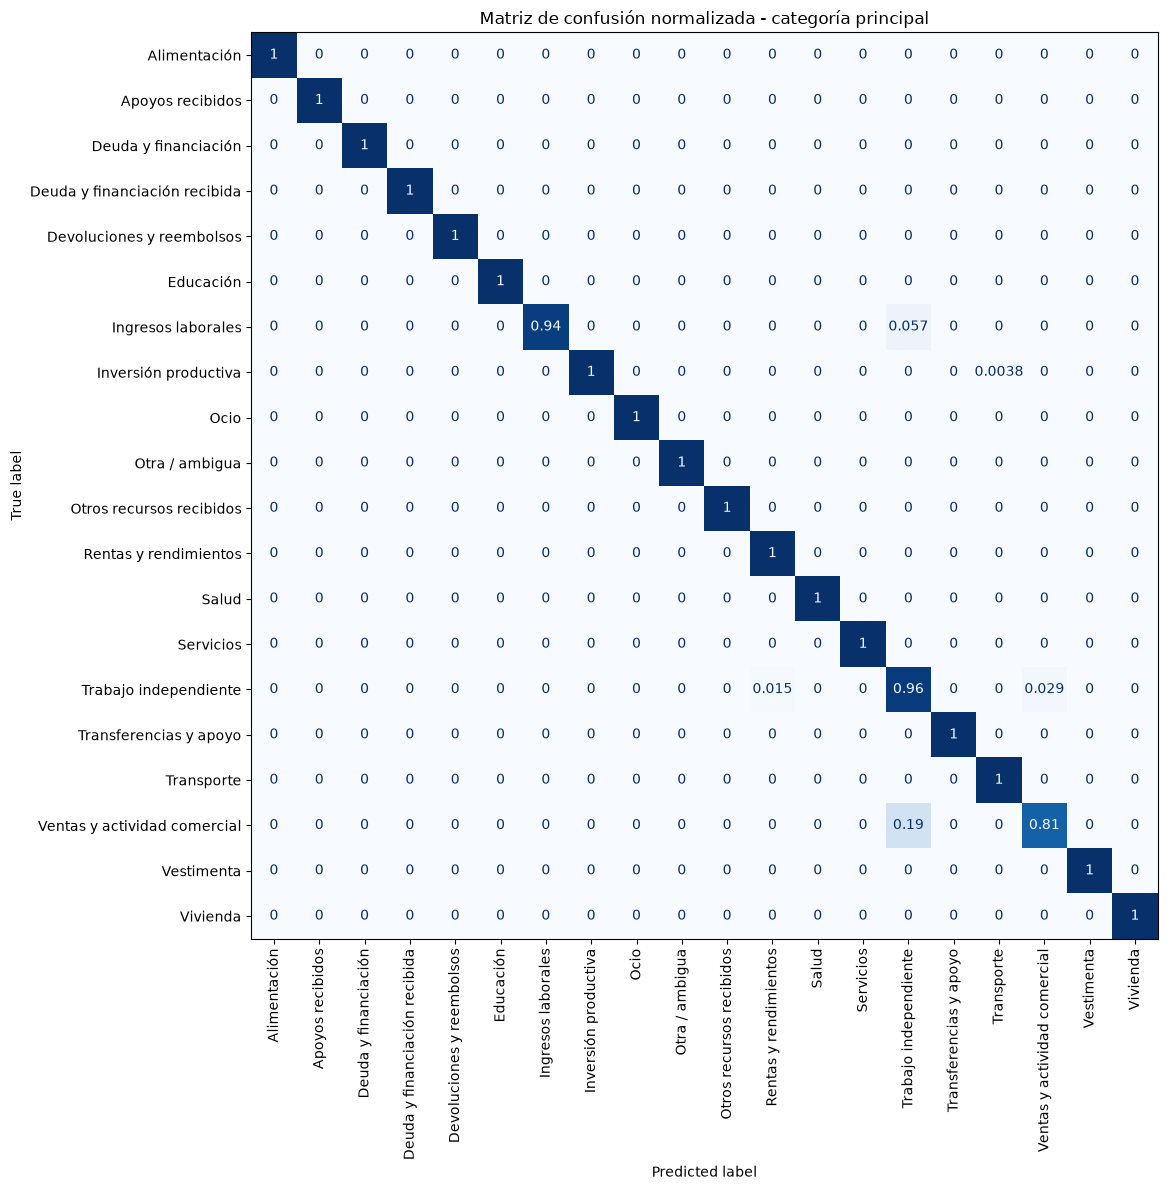

In [15]:
#Mostrar confusión
figura, eje = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_categoria_test,
    prediccion_categoria_test,
    labels=sorted(y_categoria_test.unique()),
    normalize='true',
    xticks_rotation=90,
    cmap='Blues',
    ax=eje,
    colorbar=False,
)

eje.set_title('Matriz de confusión normalizada - categoría principal')
plt.tight_layout()
plt.show()

## 8. Finalidad y confirmación

In [16]:
#Entrenar finalidad
modelo_finalidad = crear_pipeline(SGDClassifier(
    loss='log_loss',
    alpha=0.00001,
    max_iter=2000,
    class_weight='balanced',
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10,
    average=True,
    random_state=SEMILLA,
))

y_finalidad_train = datos.loc[mascara_train, 'finalidad']
y_finalidad_validation = datos.loc[mascara_validation, 'finalidad']
y_finalidad_test = datos.loc[mascara_test, 'finalidad']

modelo_finalidad.fit(X_train, y_finalidad_train)
prediccion_finalidad_validation = modelo_finalidad.predict(X_validation)
prediccion_finalidad_test = modelo_finalidad.predict(X_test)

metricas_finalidad = pd.DataFrame([{
    'f1_macro_validation': f1_score(
        y_finalidad_validation,
        prediccion_finalidad_validation,
        average='macro',
        zero_division=0,
    ),
    'f1_macro_test': f1_score(
        y_finalidad_test,
        prediccion_finalidad_test,
        average='macro',
        zero_division=0,
    ),
    'accuracy_test': accuracy_score(y_finalidad_test, prediccion_finalidad_test),
}])

display(metricas_finalidad)

,f1_macro_validation,f1_macro_test,accuracy_test
0,0.970042,0.983822,0.997332


In [17]:
#Validar compatibilidad
tabla_compatibilidad = pd.crosstab(
    datos.loc[mascara_train, 'finalidad'],
    datos.loc[mascara_train, 'categoria_principal'],
).gt(0)

categorias_por_finalidad = {
    finalidad: tabla_compatibilidad.columns[fila.to_numpy()].tolist()
    for finalidad, fila in tabla_compatibilidad.iterrows()
}

parejas_validas = set(zip(
    datos.loc[mascara_train, 'categoria_principal'],
    datos.loc[mascara_train, 'finalidad'],
))

compatibilidad_test = [
    (categoria, finalidad) in parejas_validas
    for categoria, finalidad in zip(prediccion_categoria_test, prediccion_finalidad_test)
]

metricas_compatibilidad = pd.DataFrame([{
    'parejas_validas_test_pct': round(float(np.mean(compatibilidad_test)) * 100, 2),
    'parejas_incompatibles_test': int((~np.asarray(compatibilidad_test)).sum()),
}])

display(tabla_compatibilidad)
display(metricas_compatibilidad)

categoria_principal,Alimentación,Apoyos recibidos,Deuda y financiación,Deuda y financiación recibida,Devoluciones y reembolsos,Educación,Ingresos laborales,Inversión productiva,Ocio,Otra / ambigua,Otros recursos recibidos,Rentas y rendimientos,Salud,Servicios,Trabajo independiente,Transferencias y apoyo,Transporte,Ventas y actividad comercial,Vestimenta,Vivienda
finalidad,,,,,,,,,,,,,,,,,,,,
apoyo_externo,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
apoyo_terceros,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
consumo_mixto,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
consumo_personal,True,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,True,False,True,True
generacion_ingreso,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False
hobby,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
indeterminado,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
laboral,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False
liquidez_financiada,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


,parejas_validas_test_pct,parejas_incompatibles_test
0,99.85,4


In [18]:
#Entrenar confirmación
modelo_confirmacion = crear_pipeline(SGDClassifier(
    loss='log_loss',
    alpha=0.00001,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10,
    average=True,
    random_state=SEMILLA,
))

y_confirmacion_train = datos.loc[mascara_train, 'requiere_confirmacion']
y_confirmacion_validation = datos.loc[mascara_validation, 'requiere_confirmacion']
y_confirmacion_test = datos.loc[mascara_test, 'requiere_confirmacion']

modelo_confirmacion.fit(X_train, y_confirmacion_train)
probabilidades_confirmacion_validation = modelo_confirmacion.predict_proba(X_validation)
posicion_confirmacion_si = list(modelo_confirmacion.classes_).index('si')
probabilidad_si_validation = probabilidades_confirmacion_validation[:, posicion_confirmacion_si]
resultados_umbrales_confirmacion = []

for umbral in np.arange(0.10, 1.00, 0.01):
    prediccion = np.where(probabilidad_si_validation >= umbral, 'si', 'no')
    resultados_umbrales_confirmacion.append({
        'umbral': round(float(umbral), 2),
        'f1_confirmacion': f1_score(
            y_confirmacion_validation,
            prediccion,
            pos_label='si',
            zero_division=0,
        ),
        'precision_confirmacion': precision_score(
            y_confirmacion_validation,
            prediccion,
            pos_label='si',
            zero_division=0,
        ),
        'recall_confirmacion': recall_score(
            y_confirmacion_validation,
            prediccion,
            pos_label='si',
            zero_division=0,
        ),
    })

resultados_umbrales_confirmacion = pd.DataFrame(resultados_umbrales_confirmacion)
UMBRAL_CONFIRMACION = float(
    resultados_umbrales_confirmacion.sort_values(
        ['f1_confirmacion', 'precision_confirmacion', 'umbral'],
        ascending=[False, False, False],
    ).iloc[0]['umbral']
)

probabilidades_confirmacion_test = modelo_confirmacion.predict_proba(X_test)
probabilidad_si_test = probabilidades_confirmacion_test[:, posicion_confirmacion_si]
prediccion_confirmacion_validation = np.where(
    probabilidad_si_validation >= UMBRAL_CONFIRMACION,
    'si',
    'no',
)
prediccion_confirmacion_test = np.where(
    probabilidad_si_test >= UMBRAL_CONFIRMACION,
    'si',
    'no',
)

reporte_confirmacion = classification_report(
    y_confirmacion_test,
    prediccion_confirmacion_test,
    output_dict=True,
    zero_division=0,
)

metricas_confirmacion = pd.DataFrame([{
    'f1_macro_validation': f1_score(
        y_confirmacion_validation,
        prediccion_confirmacion_validation,
        average='macro',
        zero_division=0,
    ),
    'f1_macro_test': f1_score(
        y_confirmacion_test,
        prediccion_confirmacion_test,
        average='macro',
        zero_division=0,
    ),
    'recall_requiere_confirmacion_test': reporte_confirmacion['si']['recall'],
    'precision_requiere_confirmacion_test': reporte_confirmacion['si']['precision'],
}])

display(resultados_umbrales_confirmacion)
display(metricas_confirmacion)
print(f'Umbral de confirmación seleccionado: {UMBRAL_CONFIRMACION:.2f}')

,umbral,f1_confirmacion,precision_confirmacion,recall_confirmacion
0,0.10,0.554545,0.435714,0.7625
1,0.11,0.561905,0.453846,0.7375
2,0.12,0.580000,0.483333,0.7250
3,0.13,0.588235,0.514019,0.6875
4,0.14,0.579545,0.531250,0.6375
...,...,...,...,...
85,0.95,0.315789,1.000000,0.1875
86,0.96,0.241758,1.000000,0.1375
87,0.97,0.117647,1.000000,0.0625
88,0.98,0.072289,1.000000,0.0375


,f1_macro_validation,f1_macro_test,recall_requiere_confirmacion_test,precision_requiere_confirmacion_test
0,0.851191,0.837962,0.518987,1.0


Umbral de confirmación seleccionado: 0.57


In [19]:
#Evaluar abstención
probabilidades_categoria_validation = modelo_categoria.predict_proba(X_validation)
confianza_categoria_validation = probabilidades_categoria_validation.max(axis=1)
aceptadas = confianza_categoria_validation >= UMBRAL_TRANSACCION

exactitud_aceptadas = accuracy_score(
    y_categoria_validation[aceptadas],
    modelo_categoria.predict(X_validation)[aceptadas],
) if aceptadas.any() else np.nan

resumen_abstencion = pd.DataFrame([{
    'umbral': UMBRAL_TRANSACCION,
    'cobertura_validation_pct': round(float(aceptadas.mean()) * 100, 2),
    'abstencion_validation_pct': round(float((~aceptadas).mean()) * 100, 2),
    'accuracy_en_aceptadas': exactitud_aceptadas,
}])

display(resumen_abstencion)

,umbral,cobertura_validation_pct,abstencion_validation_pct,accuracy_en_aceptadas
0,0.5,99.45,0.55,0.995229


## 9. Regularidad de gastos e ingresos

Los gastos se clasifican como fijos o variables. Los ingresos se entrenan por separado porque también pueden ser estacionales. El historial utilizado corresponde únicamente a movimientos anteriores.

In [20]:
#Validar entradas de regularidad
columnas_prohibidas_regularidad = [
    'regularidad_movimiento',
    'es_recurrente',
    'criterio_regularidad',
    'fuente_regularidad',
    'regularidad_confirmada_usuario',
]
columnas_filtradas = set(columnas_modelo_regularidad) & set(columnas_prohibidas_regularidad)

assert not columnas_filtradas, f'Hay fuga de información en regularidad: {columnas_filtradas}'
display(pd.DataFrame([
    {'grupo': 'entradas permitidas', 'columnas': ' | '.join(columnas_modelo_regularidad)},
    {'grupo': 'columnas prohibidas', 'columnas': ' | '.join(columnas_prohibidas_regularidad)},
]))

,grupo,columnas
0,entradas permitidas,texto_modelo | valor_modelo | proporcion_ingre...
1,columnas prohibidas,regularidad_movimiento | es_recurrente | crite...


In [21]:
#Entrenar regularidad
mascara_gastos = datos['direccion'].eq('salida')
mascara_ingresos = datos['direccion'].eq('entrada')
modelo_regularidad_gastos = crear_pipeline_regularidad()
modelo_regularidad_ingresos = crear_pipeline_regularidad()

modelo_regularidad_gastos.fit(
    X_regularidad.loc[mascara_train & mascara_gastos],
    datos.loc[mascara_train & mascara_gastos, 'regularidad_movimiento'],
)
modelo_regularidad_ingresos.fit(
    X_regularidad.loc[mascara_train & mascara_ingresos],
    datos.loc[mascara_train & mascara_ingresos, 'regularidad_movimiento'],
)
descripciones_regularidad_entrenadas = set(
    datos.loc[mascara_train, 'descripcion_normalizada'].dropna().astype(str).str.strip().str.lower()
)
catalogo_descripciones_regularidad = sorted(descripciones_regularidad_entrenadas)
vectorizador_descripciones_regularidad = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    lowercase=True,
    strip_accents='unicode',
)
matriz_descripciones_regularidad = vectorizador_descripciones_regularidad.fit_transform(catalogo_descripciones_regularidad)

clases_regularidad = pd.DataFrame([
    {'modelo': 'gastos', 'clases': ' | '.join(modelo_regularidad_gastos.classes_)},
    {'modelo': 'ingresos', 'clases': ' | '.join(modelo_regularidad_ingresos.classes_)},
])

assert set(modelo_regularidad_gastos.classes_) == {'fijo', 'variable'}, 'Las clases del modelo de gastos son incorrectas'
assert set(modelo_regularidad_ingresos.classes_) == {'fijo', 'variable', 'estacional'}, 'Las clases del modelo de ingresos son incorrectas'
display(clases_regularidad)

,modelo,clases
0,gastos,fijo | variable
1,ingresos,estacional | fijo | variable


In [22]:
#Evaluar regularidad
def evaluar_regularidad(nombre, modelo, mascara_tipo):
    resultados = []

    for particion in ['validation', 'test']:
        mascara_particion = datos['particion'].eq(particion) & mascara_tipo

        for segmento, mascara_historial in [
            ('total', pd.Series(True, index=datos.index)),
            ('con_historial', datos['historial_regularidad_disponible'].eq('si')),
            ('sin_historial', datos['historial_regularidad_disponible'].eq('no')),
        ]:
            mascara_evaluacion = mascara_particion & mascara_historial
            reales = datos.loc[mascara_evaluacion, 'regularidad_movimiento']
            predichas = modelo.predict(X_regularidad.loc[mascara_evaluacion])
            resultados.append({
                'modelo': nombre,
                'particion': particion,
                'segmento': segmento,
                'filas': len(reales),
                'accuracy': accuracy_score(reales, predichas),
                'f1_macro': f1_score(reales, predichas, average='macro', zero_division=0),
            })

    return resultados


metricas_regularidad = pd.DataFrame(
    evaluar_regularidad('gastos', modelo_regularidad_gastos, mascara_gastos)
    + evaluar_regularidad('ingresos', modelo_regularidad_ingresos, mascara_ingresos)
)

display(metricas_regularidad)

,modelo,particion,segmento,filas,accuracy,f1_macro
0,gastos,validation,total,2237,0.974072,0.972306
1,gastos,validation,con_historial,800,0.985000,0.984986
2,gastos,validation,sin_historial,1437,0.967989,0.961525
3,gastos,test,total,2297,0.976491,0.974240
4,gastos,test,con_historial,817,0.992656,0.992650
5,gastos,test,sin_historial,1480,0.967568,0.959638
6,ingresos,validation,total,292,0.907534,0.883471
7,ingresos,validation,con_historial,152,1.000000,1.000000
8,ingresos,validation,sin_historial,140,0.807143,0.845661
9,ingresos,test,total,327,0.911315,0.888129


## 10. Uso del modelo de usuario

In [23]:
#Preparar modelo de usuario
def normalizar_texto(texto):
    texto = unicodedata.normalize('NFKD', str(texto).lower())
    texto = ''.join(caracter for caracter in texto if not unicodedata.combining(caracter))
    texto = texto.replace('_', ' ').replace('-', ' ')
    return ' '.join(texto.split())


def puntuar_actividad_usuario(texto):
    modelo = artefacto_usuario['modelo_actividad']
    probabilidades = dict(zip(modelo.classes_, modelo.predict_proba([texto])[0]))
    vector = artefacto_usuario['vectorizador_catalogo'].transform([texto])
    similitudes = cosine_similarity(vector, artefacto_usuario['matriz_catalogo'])[0]
    familias = artefacto_usuario['familias_catalogo']
    resultados = []

    for actividad in modelo.classes_:
        similitud = float(similitudes[familias == actividad].max())
        probabilidad = float(probabilidades[actividad])
        confianza = (
            artefacto_usuario['peso_modelo'] * probabilidad
            + artefacto_usuario['peso_catalogo'] * similitud
        )
        resultados.append({
            'actividad': str(actividad),
            'confianza': confianza,
        })

    return sorted(resultados, key=lambda resultado: resultado['confianza'], reverse=True)


def clasificar_hobbies_usuario(hobbies):
    if isinstance(hobbies, (list, tuple, set)):
        texto = ' | '.join(str(hobby) for hobby in hobbies)
    else:
        texto = str(hobbies or '')

    texto_normalizado = normalizar_texto(texto)
    palabras = set(texto_normalizado.replace('|', ' ').replace(',', ' ').replace(';', ' ').split())
    encontrados = []

    for hobby, variantes in artefacto_usuario['variantes_hobbies'].items():
        for variante in variantes:
            variante_normalizada = normalizar_texto(variante)
            coincide = (
                variante_normalizada in texto_normalizado
                if ' ' in variante_normalizada
                else variante_normalizada in palabras
            )
            if coincide:
                encontrados.append(hobby)
                break

    return encontrados if encontrados else ['no_declarado']

In [24]:
#Clasificar usuario
def conocer_usuario(test_usuario):
    if not isinstance(test_usuario, dict):
        raise TypeError('test_usuario debe ser un diccionario')

    actividad_declarada = str(
        test_usuario.get('actividad_principal_declarada')
        or test_usuario.get('ingreso_principal')
        or ''
    ).strip()
    if not actividad_declarada:
        raise ValueError('actividad_principal_declarada debe contener texto')

    resultados = puntuar_actividad_usuario(actividad_declarada)
    mejor_resultado = resultados[0]
    confianza = mejor_resultado['confianza']
    dentro_mvp = confianza >= artefacto_usuario['umbral_alcance']
    actividad = mejor_resultado['actividad'] if dentro_mvp else 'no_disponible'

    ingreso_mensual = float(test_usuario.get('ingreso_mensual_neto', 0))
    modalidad = str(test_usuario.get('modalidad_ingreso_principal', '')).strip().lower()
    estado_ingreso = 'sin_ingresos' if ingreso_mensual == 0 else modalidad
    if estado_ingreso not in artefacto_usuario['modalidades_ingreso']:
        raise ValueError('modalidad_ingreso_principal no es válida')

    ingreso_adicional = str(test_usuario.get('ingreso_adicional', '') or '').strip()
    actividad_secundaria = 'no_declarada'
    if test_usuario.get('tiene_ingreso_adicional') and ingreso_adicional:
        resultado_secundario = puntuar_actividad_usuario(ingreso_adicional)[0]
        actividad_secundaria = (
            resultado_secundario['actividad']
            if resultado_secundario['confianza'] >= artefacto_usuario['umbral_alcance']
            else 'fuera_del_mvp'
        )

    tipos_deuda = test_usuario.get('tipos_deuda', [])
    if isinstance(tipos_deuda, (list, tuple, set)):
        tipos_deuda = ' | '.join(str(deuda) for deuda in tipos_deuda)

    return {
        'estado_alcance_mvp': 'dentro_del_mvp' if dentro_mvp else 'no_disponible',
        'actividad_principal': actividad,
        'actividad_secundaria': actividad_secundaria,
        'estado_ingreso_actual': estado_ingreso,
        'ingreso_mensual_neto': ingreso_mensual,
        'hobbies_intereses': clasificar_hobbies_usuario(test_usuario.get('hobbies', [])),
        'meta': str(test_usuario.get('objetivo_proximo', '') or 'no_declarada').strip(),
        'responsabilidad': str(test_usuario.get('responsabilidad_financiera', '') or 'no_declarada').strip(),
        'tipos_deuda': str(tipos_deuda or 'sin_deuda'),
        'nivel_endeudamiento_pct': test_usuario.get('nivel_endeudamiento_pct'),
        'habito_ahorro': str(test_usuario.get('habito_ahorro', 'no_declarado')).strip().lower(),
        'confianza_usuario_pct': round(confianza * 100, 2),
    }

## 11. Clasificación completa

In [25]:
#Clasificar transacción
def detectar_tipo_movimiento(descripcion, direccion, tipo_declarado=''):
    palabras = set(normalizar_texto(descripcion).split())
    es_pago = bool({'pago', 'cuota'} & palabras)
    es_deuda = bool({'credito', 'prestamo'} & palabras)

    if direccion == 'salida' and es_pago and es_deuda:
        return 'pago_deuda'
    if tipo_declarado:
        return tipo_declarado
    return 'ingreso_generado' if direccion == 'entrada' else 'gasto'


def preparar_historial_regularidad(test_transaccion):
    estado_historial = str(test_transaccion.get('historial_regularidad_disponible', 'no')).strip().lower()
    if estado_historial not in ['si', 'no']:
        raise ValueError('historial_regularidad_disponible debe ser si o no')

    def convertir_numero(clave, reemplazo):
        numero = pd.to_numeric(test_transaccion.get(clave, reemplazo), errors='coerce')
        return reemplazo if pd.isna(numero) else float(numero)

    return {
        'ocurrencias_previas_90d': convertir_numero('ocurrencias_previas_90d', 0),
        'meses_previos_con_movimiento': convertir_numero('meses_previos_con_movimiento', 0),
        'dias_desde_movimiento_similar': convertir_numero('dias_desde_movimiento_similar', np.nan),
        'variacion_valor_previa_pct': convertir_numero('variacion_valor_previa_pct', np.nan),
        'historial_disponible_modelo': 1 if estado_historial == 'si' else 0,
    }


def clasificar_transaccion(test_usuario, test_transaccion):
    if not isinstance(test_transaccion, dict):
        raise TypeError('test_transaccion debe ser un diccionario')

    contexto = conocer_usuario(test_usuario)
    descripcion = str(test_transaccion.get('descripcion', '')).strip()
    nota_usuario = str(test_transaccion.get('nota_usuario', '') or '').strip()
    valor_numerico = float(test_transaccion.get('valor', 0))
    direccion = str(test_transaccion.get('direccion', 'salida')).strip().lower()

    if not descripcion:
        raise ValueError('descripcion debe contener texto')
    if valor_numerico <= 0:
        raise ValueError('valor debe ser mayor que cero')
    if direccion not in ['entrada', 'salida']:
        raise ValueError('direccion debe ser entrada o salida')

    tipo_movimiento = detectar_tipo_movimiento(
        descripcion,
        direccion,
        str(test_transaccion.get('tipo_movimiento', '') or '').strip(),
    )
    hobbies_modelo = ' | '.join(contexto['hobbies_intereses'])
    fila = {
        'descripcion_normalizada': normalizar_texto(descripcion),
        'nota_usuario': nota_usuario,
        'direccion': direccion,
        'tipo_movimiento': tipo_movimiento,
        'actividad_1_familia': contexto['actividad_principal'],
        'actividad_secundaria_modelo': contexto['actividad_secundaria'],
        'estado_ingreso_actual': contexto['estado_ingreso_actual'],
        'hobbies_modelo': hobbies_modelo,
        'meta_modelo': contexto['meta'],
        'responsabilidad_modelo': contexto['responsabilidad'],
        'deuda_modelo': contexto['tipos_deuda'],
        'habito_ahorro': contexto['habito_ahorro'],
    }
    proporcion_ingreso = valor_numerico / max(contexto['ingreso_mensual_neto'], 1)
    entrada = pd.DataFrame([{
        'texto_modelo': construir_texto_modelo(fila),
        'valor_modelo': np.log1p(valor_numerico) / escala_valor,
        'proporcion_ingreso_modelo': np.log1p(proporcion_ingreso) / escala_proporcion,
    }])
    historial_regularidad = preparar_historial_regularidad(test_transaccion)
    entrada_regularidad = entrada.assign(**historial_regularidad)

    probabilidades_categoria = modelo_categoria.predict_proba(entrada)[0]
    probabilidades_finalidad = modelo_finalidad.predict_proba(entrada)[0]
    modelo_regularidad = modelo_regularidad_ingresos if direccion == 'entrada' else modelo_regularidad_gastos
    probabilidades_regularidad = modelo_regularidad.predict_proba(entrada_regularidad)[0]
    regla_aplicada = 'modelo_contextual'

    if tipo_movimiento == 'pago_deuda':
        probabilidades_categoria = np.zeros_like(probabilidades_categoria)
        posicion_deuda = list(modelo_categoria.classes_).index('Deuda y financiación')
        probabilidades_categoria[posicion_deuda] = 1.0
        finalidad = 'pago_deuda'
        confianza_finalidad = 1.0
        regla_aplicada = 'pago_deuda_explicito'
    else:
        posicion_finalidad = int(np.argmax(probabilidades_finalidad))
        finalidad = str(modelo_finalidad.classes_[posicion_finalidad])
        confianza_finalidad = float(probabilidades_finalidad[posicion_finalidad])

    orden = np.argsort(probabilidades_categoria)[::-1]
    categoria_principal = str(modelo_categoria.classes_[orden[0]])
    confianza_categoria = float(probabilidades_categoria[orden[0]])
    top_3_categorias = [
        {
            'categoria': str(modelo_categoria.classes_[posicion]),
            'porcentaje': round(float(probabilidades_categoria[posicion]) * 100, 2),
        }
        for posicion in orden[:3]
        if probabilidades_categoria[posicion] > 0
    ]
    porcentajes_categorias = {
        str(modelo_categoria.classes_[posicion]): round(float(probabilidades_categoria[posicion]) * 100, 2)
        for posicion in orden
    }

    posicion_regularidad = int(np.argmax(probabilidades_regularidad))
    regularidad = str(modelo_regularidad.classes_[posicion_regularidad])
    confianza_regularidad_modelo = float(probabilidades_regularidad[posicion_regularidad])
    vector_descripcion = vectorizador_descripciones_regularidad.transform([normalizar_texto(descripcion)])
    similitud_descripcion = float(cosine_similarity(vector_descripcion, matriz_descripciones_regularidad).max())
    descripcion_conocida = similitud_descripcion >= 0.40
    historial_disponible = historial_regularidad['historial_disponible_modelo'] == 1
    factor_evidencia = 1.0 if historial_disponible else 0.45 + 0.55 * similitud_descripcion
    confianza_regularidad = confianza_regularidad_modelo * factor_evidencia
    if not historial_disponible and not descripcion_conocida:
        confianza_regularidad = min(confianza_regularidad, 0.49)
    requiere_confirmacion_regularidad = (
        confianza_regularidad < UMBRAL_REGULARIDAD
        or (not historial_disponible and not descripcion_conocida)
    )

    probabilidades_confirmacion = modelo_confirmacion.predict_proba(entrada)[0]
    posicion_si = list(modelo_confirmacion.classes_).index('si')
    probabilidad_confirmacion = float(probabilidades_confirmacion[posicion_si])
    pareja_compatible = (categoria_principal, finalidad) in parejas_validas
    categoria_contextual = categoria_principal in ['Ocio', 'Inversión productiva', 'Trabajo independiente']

    requiere_confirmacion_categoria = (
        confianza_categoria < UMBRAL_TRANSACCION
        or categoria_principal == 'Otra / ambigua'
        or probabilidad_confirmacion >= UMBRAL_CONFIRMACION
        or not pareja_compatible
        or (contexto['estado_alcance_mvp'] == 'no_disponible' and categoria_contextual)
    )
    if regla_aplicada == 'pago_deuda_explicito':
        requiere_confirmacion_categoria = False
        probabilidad_confirmacion = 0.0

    requiere_confirmacion = requiere_confirmacion_categoria or requiere_confirmacion_regularidad

    return {
        'descripcion_transaccion': descripcion,
        'nota_usuario': nota_usuario,
        'valor': valor_numerico,
        'direccion': direccion,
        'tipo_movimiento': tipo_movimiento,
        'estado_alcance_usuario': contexto['estado_alcance_mvp'],
        'actividad_usuario': contexto['actividad_principal'],
        'estado_ingreso_usuario': contexto['estado_ingreso_actual'],
        'hobbies_usuario': contexto['hobbies_intereses'],
        'categoria_principal': categoria_principal,
        'confianza_categoria_pct': round(confianza_categoria * 100, 2),
        'porcentajes_categorias': porcentajes_categorias,
        'top_3_categorias': top_3_categorias,
        'finalidad': finalidad,
        'confianza_finalidad_pct': round(confianza_finalidad * 100, 2),
        'regularidad_movimiento': regularidad,
        'confianza_regularidad_pct': round(confianza_regularidad * 100, 2),
        'confianza_regularidad_modelo_pct': round(confianza_regularidad_modelo * 100, 2),
        'similitud_descripcion_regularidad_pct': round(similitud_descripcion * 100, 2),
        'historial_regularidad_disponible': 'si' if historial_disponible else 'no',
        'descripcion_regularidad_conocida': 'si' if descripcion_conocida else 'no',
        'requiere_confirmacion_regularidad': 'si' if requiere_confirmacion_regularidad else 'no',
        'requiere_confirmacion_categoria': 'si' if requiere_confirmacion_categoria else 'no',
        'requiere_confirmacion': 'si' if requiere_confirmacion else 'no',
        'probabilidad_confirmacion_pct': round(probabilidad_confirmacion * 100, 2),
        'estado_clasificacion': 'requiere_confirmacion' if requiere_confirmacion else 'clasificada',
        'pareja_categoria_finalidad_valida': pareja_compatible,
        'regla_aplicada': regla_aplicada,
        'advertencia_contexto': (
            'La actividad del usuario está fuera del catálogo profesional del MVP'
            if contexto['estado_alcance_mvp'] == 'no_disponible'
            else 'Contexto del usuario reconocido dentro del MVP'
        ),
        'version_modelo': VERSION_MODELO,
    }

## 12. Serialización

In [26]:
#Guardar modelo
ruta_modelo_transacciones = Path('../Modelos/02_clasificacion_transacciones.joblib')
ruta_modelo_transacciones.parent.mkdir(parents=True, exist_ok=True)

artefacto_transacciones = {
    'version_modelo': VERSION_MODELO,
    'modelo_categoria': modelo_categoria,
    'nombre_modelo_categoria': nombre_modelo_categoria,
    'modelo_finalidad': modelo_finalidad,
    'modelo_regularidad_gastos': modelo_regularidad_gastos,
    'modelo_regularidad_ingresos': modelo_regularidad_ingresos,
    'modelo_confirmacion': modelo_confirmacion,
    'umbral_transaccion': UMBRAL_TRANSACCION,
    'umbral_confirmacion': UMBRAL_CONFIRMACION,
    'umbral_regularidad': UMBRAL_REGULARIDAD,
    'categorias_por_finalidad': categorias_por_finalidad,
    'parejas_validas': parejas_validas,
    'escala_valor': escala_valor,
    'escala_proporcion': escala_proporcion,
    'columnas_modelo': columnas_modelo,
    'columnas_modelo_regularidad': columnas_modelo_regularidad,
    'columnas_historial': columnas_historial,
    'descripciones_regularidad_entrenadas': descripciones_regularidad_entrenadas,
    'catalogo_descripciones_regularidad': catalogo_descripciones_regularidad,
    'vectorizador_descripciones_regularidad': vectorizador_descripciones_regularidad,
    'matriz_descripciones_regularidad': matriz_descripciones_regularidad,
    'umbral_similitud_regularidad': 0.40,
    'definicion_regularidad': {
        'gasto_fijo': 'Compromiso periódico cuyo valor y fecha son previsibles',
        'gasto_variable': 'Compra o consumo cuyo valor, momento o decisión puede cambiar',
        'recurrencia': 'Repetición observada; no convierte automáticamente un gasto en fijo',
    },
    'version_modelo_usuario': artefacto_usuario['version_modelo'],
}

joblib.dump(artefacto_transacciones, ruta_modelo_transacciones)
print(f'Modelo guardado en: {ruta_modelo_transacciones}')

Modelo guardado en: ../Modelos/02_clasificacion_transacciones.joblib


## 13. Pruebas manuales

In [27]:
#Probar categorías
usuario_editor = {
    'actividad_principal_declarada': 'Editor de video',
    'ingreso_mensual_neto': 4200000,
    'modalidad_ingreso_principal': 'variable',
    'tiene_ingreso_adicional': False,
    'ingreso_adicional': '',
    'objetivo_proximo': 'comprar equipo de trabajo',
    'hobbies': ['turismo y viajes'],
    'responsabilidad_financiera': 'aporte al hogar',
    'tipos_deuda': ['credito'],
    'nivel_endeudamiento_pct': 18,
    'habito_ahorro': 'media',
}

usuario_software = {
    'actividad_principal_declarada': 'Desarrollador de software',
    'ingreso_mensual_neto': 5500000,
    'modalidad_ingreso_principal': 'fijo',
    'tiene_ingreso_adicional': False,
    'ingreso_adicional': '',
    'objetivo_proximo': 'crear un fondo de emergencia',
    'hobbies': ['videojuegos y streaming'],
    'responsabilidad_financiera': '',
    'tipos_deuda': [],
    'nivel_endeudamiento_pct': 0,
    'habito_ahorro': 'alta',
}

usuario_nutricion = {
    'actividad_principal_declarada': 'Nutricionista',
    'ingreso_mensual_neto': 2800000,
    'modalidad_ingreso_principal': 'mixto',
    'tiene_ingreso_adicional': False,
    'ingreso_adicional': '',
    'objetivo_proximo': 'ampliar actividad economica',
    'hobbies': ['cocina y reposteria'],
    'responsabilidad_financiera': 'gastos de un hijo',
    'tipos_deuda': ['credito'],
    'nivel_endeudamiento_pct': 22,
    'habito_ahorro': 'baja',
}

test_transacciones = [
    {
        'test_usuario': usuario_editor,
        'test_transaccion': {'descripcion': 'COMPRA COMPUTADOR', 'valor': 4500000, 'direccion': 'salida', 'nota_usuario': 'Herramienta para mi trabajo de edicion de video'},
        'categoria_esperada': 'Inversión productiva',
    },
    {
        'test_usuario': usuario_software,
        'test_transaccion': {'descripcion': 'COMPRA COMPUTADOR', 'valor': 4500000, 'direccion': 'salida', 'nota_usuario': 'Para videojuegos y streaming en mi tiempo libre'},
        'categoria_esperada': 'Ocio',
    },
    {
        'test_usuario': usuario_nutricion,
        'test_transaccion': {'descripcion': 'COMPRA MERCADO', 'valor': 180000, 'direccion': 'salida', 'nota_usuario': ''},
        'categoria_esperada': 'Alimentación',
    },
    {
        'test_usuario': usuario_nutricion,
        'test_transaccion': {'descripcion': 'PAGO CREDITO', 'valor': 150000, 'direccion': 'salida', 'nota_usuario': 'credito educativo'},
        'categoria_esperada': 'Deuda y financiación',
    },
]

resultados_transacciones = []

for caso in test_transacciones:
    resultado = clasificar_transaccion(caso['test_usuario'], caso['test_transaccion'])
    resultado['categoria_esperada'] = caso['categoria_esperada']
    resultado['cumple_esperado'] = resultado['categoria_principal'] == caso['categoria_esperada']
    resultados_transacciones.append(resultado)

columnas_prueba = [
    'descripcion_transaccion',
    'actividad_usuario',
    'hobbies_usuario',
    'categoria_principal',
    'categoria_esperada',
    'confianza_categoria_pct',
    'top_3_categorias',
    'porcentajes_categorias',
    'finalidad',
    'confianza_finalidad_pct',
    'regularidad_movimiento',
    'requiere_confirmacion_categoria',
    'requiere_confirmacion_regularidad',
    'requiere_confirmacion',
    'cumple_esperado',
]

resultados_transacciones = pd.DataFrame(resultados_transacciones)
display(resultados_transacciones[columnas_prueba])
assert resultados_transacciones['cumple_esperado'].all(), 'Una categoría no cumplió la salida esperada'

,descripcion_transaccion,actividad_usuario,hobbies_usuario,categoria_principal,categoria_esperada,confianza_categoria_pct,top_3_categorias,porcentajes_categorias,finalidad,confianza_finalidad_pct,regularidad_movimiento,requiere_confirmacion_categoria,requiere_confirmacion_regularidad,requiere_confirmacion,cumple_esperado
0,COMPRA COMPUTADOR,diseno_audiovisual_y_edicion_de_video,[turismo_y_viajes],Inversión productiva,Inversión productiva,91.45,"[{'categoria': 'Inversión productiva', 'porcen...","{'Inversión productiva': 91.45, 'Educación': 6...",laboral,98.79,variable,no,no,no,True
1,COMPRA COMPUTADOR,ingenieria_y_desarrollo_de_software,[videojuegos_y_streaming],Ocio,Ocio,74.84,"[{'categoria': 'Ocio', 'porcentaje': 74.84}, {...","{'Ocio': 74.84, 'Inversión productiva': 21.32,...",hobby,78.75,variable,no,no,no,True
2,COMPRA MERCADO,nutricion_y_dietetica,[cocina_y_reposteria],Alimentación,Alimentación,86.98,"[{'categoria': 'Alimentación', 'porcentaje': 8...","{'Alimentación': 86.98, 'Otra / ambigua': 8.71...",consumo_personal,78.48,variable,no,no,no,True
3,PAGO CREDITO,nutricion_y_dietetica,[cocina_y_reposteria],Deuda y financiación,Deuda y financiación,100.00,"[{'categoria': 'Deuda y financiación', 'porcen...","{'Deuda y financiación': 100.0, 'Vivienda': 0....",pago_deuda,100.00,fijo,no,no,no,True


In [28]:
#Probar regularidad
test_regularidad = [
    {
        'descripcion': 'PAGO ARRIENDO',
        'valor': 1200000,
        'direccion': 'salida',
        'ocurrencias_previas_90d': 2,
        'meses_previos_con_movimiento': 2,
        'dias_desde_movimiento_similar': 30,
        'variacion_valor_previa_pct': 2,
        'historial_regularidad_disponible': 'si',
        'regularidad_esperada': 'fijo',
        'confirmacion_esperada': 'no',
    },
    {
        'descripcion': 'NETFLIX',
        'valor': 44900,
        'direccion': 'salida',
        'ocurrencias_previas_90d': 2,
        'meses_previos_con_movimiento': 2,
        'dias_desde_movimiento_similar': 30,
        'variacion_valor_previa_pct': 0,
        'historial_regularidad_disponible': 'si',
        'regularidad_esperada': 'fijo',
        'confirmacion_esperada': 'no',
    },
    {
        'descripcion': 'LIBRO DIGITAL',
        'valor': 65000,
        'direccion': 'salida',
        'historial_regularidad_disponible': 'no',
        'regularidad_esperada': 'variable',
        'confirmacion_esperada': 'no',
    },
    {
        'descripcion': 'SUPERMERCADO',
        'valor': 280000,
        'direccion': 'salida',
        'ocurrencias_previas_90d': 8,
        'meses_previos_con_movimiento': 2,
        'dias_desde_movimiento_similar': 7,
        'variacion_valor_previa_pct': 18,
        'historial_regularidad_disponible': 'si',
        'regularidad_esperada': 'variable',
        'confirmacion_esperada': 'no',
    },
    {
        'descripcion': 'RECARGA TRANSPORTE',
        'valor': 120000,
        'direccion': 'salida',
        'ocurrencias_previas_90d': 5,
        'meses_previos_con_movimiento': 2,
        'dias_desde_movimiento_similar': 12,
        'variacion_valor_previa_pct': 25,
        'historial_regularidad_disponible': 'si',
        'regularidad_esperada': 'variable',
        'confirmacion_esperada': 'no',
    },
    {
        'descripcion': 'LEGO',
        'valor': 180000,
        'direccion': 'salida',
        'historial_regularidad_disponible': 'no',
        'regularidad_esperada': '',
        'confirmacion_esperada': 'si',
    },
]

resultados_regularidad = []

for caso in test_regularidad:
    regularidad_esperada = caso['regularidad_esperada']
    confirmacion_esperada = caso['confirmacion_esperada']
    entrada_caso = {clave: valor for clave, valor in caso.items() if clave not in ['regularidad_esperada', 'confirmacion_esperada']}
    resultado = clasificar_transaccion(usuario_software, entrada_caso)
    resultado['regularidad_esperada'] = regularidad_esperada or 'sin_clase_forzada'
    resultado['confirmacion_esperada'] = confirmacion_esperada
    resultado['cumple_regularidad'] = not regularidad_esperada or resultado['regularidad_movimiento'] == regularidad_esperada
    resultado['cumple_confirmacion'] = resultado['requiere_confirmacion_regularidad'] == confirmacion_esperada
    resultados_regularidad.append(resultado)

resultados_regularidad = pd.DataFrame(resultados_regularidad)
display(resultados_regularidad[[
    'descripcion_transaccion',
    'regularidad_movimiento',
    'regularidad_esperada',
    'confianza_regularidad_pct',
    'confianza_regularidad_modelo_pct',
    'similitud_descripcion_regularidad_pct',
    'historial_regularidad_disponible',
    'descripcion_regularidad_conocida',
    'requiere_confirmacion_regularidad',
    'confirmacion_esperada',
    'cumple_regularidad',
    'cumple_confirmacion',
]])
assert resultados_regularidad[['cumple_regularidad', 'cumple_confirmacion']].all().all(), 'Algún caso de regularidad no cumplió la salida esperada'

,descripcion_transaccion,regularidad_movimiento,regularidad_esperada,confianza_regularidad_pct,confianza_regularidad_modelo_pct,similitud_descripcion_regularidad_pct,historial_regularidad_disponible,descripcion_regularidad_conocida,requiere_confirmacion_regularidad,confirmacion_esperada,cumple_regularidad,cumple_confirmacion
0,PAGO ARRIENDO,fijo,fijo,100.00,100.00,100.00,si,si,no,no,True,True
1,NETFLIX,fijo,fijo,100.00,100.00,100.00,si,si,no,no,True,True
2,LIBRO DIGITAL,variable,variable,100.00,100.00,100.00,no,si,no,no,True,True
3,SUPERMERCADO,variable,variable,99.99,99.99,100.00,si,si,no,no,True,True
4,RECARGA TRANSPORTE,variable,variable,100.00,100.00,100.00,si,si,no,no,True,True
5,LEGO,variable,sin_clase_forzada,49.00,100.00,30.39,no,no,si,si,True,True


In [29]:
#Probar caso ambiguo
test_ambiguo = {
    'descripcion': 'PAGO QR',
    'valor': 85000,
    'direccion': 'salida',
    'nota_usuario': '',
    'salida_esperada': 'requiere_confirmacion',
}

salida_esperada = test_ambiguo['salida_esperada']
test_transaccion = {clave: valor for clave, valor in test_ambiguo.items() if clave != 'salida_esperada'}
resultado_ambiguo = clasificar_transaccion(usuario_software, test_transaccion)
resultado_ambiguo['salida_esperada'] = salida_esperada
resultado_ambiguo['cumple_esperado'] = (
    resultado_ambiguo['estado_clasificacion'] == salida_esperada
)

display(pd.DataFrame([resultado_ambiguo]))
assert resultado_ambiguo['cumple_esperado'], 'El caso ambiguo no solicitó confirmación'

,descripcion_transaccion,nota_usuario,valor,direccion,tipo_movimiento,estado_alcance_usuario,actividad_usuario,estado_ingreso_usuario,hobbies_usuario,categoria_principal,...,requiere_confirmacion_categoria,requiere_confirmacion,probabilidad_confirmacion_pct,estado_clasificacion,pareja_categoria_finalidad_valida,regla_aplicada,advertencia_contexto,version_modelo,salida_esperada,cumple_esperado
0,PAGO QR,,85000.0,salida,gasto,dentro_del_mvp,ingenieria_y_desarrollo_de_software,fijo,[videojuegos_y_streaming],Otra / ambigua,...,si,si,84.01,requiere_confirmacion,True,modelo_contextual,Contexto del usuario reconocido dentro del MVP,fincoach_transacciones_mvp_v3,requiere_confirmacion,True
